### <center> 📘 Limit Order Book reconstruction & microstructure analysis </center>

> Author : Rokhaya Sonko

---
**Objective**

This notebook builds a complete Level 1 microstructure framework.

The goal is to :

1. Reconstruct a Level 1 Limit Order Book
2. Engineer all relevant Level 1 liquidity indicators
3. Analyze liquidity dimensions (tightness, depth, stability)
4. Test predictive power at multiple horizons
5. Compare model performance across liquidity regimes
6. Interpret results economically

This is not a trading strategy. It is a microstructure signal validation framework.

---

#### 1️⃣ Imports & Setup

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)



#### Data Set

**Assumptions**
- Mid price follows a random walk  
- Spread fluctuates around a stable mean  
- Bid and ask volumes are randomly distributed within realistic bounds  

This simulation does **not** capture:
- Order flow autocorrelation  
- Spread–depth interaction  
- Volatility clustering  
- Queue dynamics  

It validates the framework structure, not real exchange microstructure.

In [62]:
n = 15000

mid = 100 + np.cumsum(np.random.normal(0, 0.01, n))
spread = np.abs(np.random.normal(0.02, 0.005, n))

best_bid = mid - spread/2
best_ask = mid + spread/2

bid_volume = np.random.randint(100, 1000, n)
ask_volume = np.random.randint(100, 1000, n)

data = pd.DataFrame({
    "mid_price": mid,
    "best_bid": best_bid,
    "best_ask": best_ask,
    "spread": spread,
    "bid_volume": bid_volume,
    "ask_volume": ask_volume
})
data.head()

,mid_price,best_bid,best_ask,spread,bid_volume,ask_volume
0,100.004967,99.995326,100.014609,0.019283,991,766
1,100.003584,99.993666,100.013503,0.019837,597,816
2,100.010061,99.999901,100.020222,0.020321,975,655
3,100.025292,100.012925,100.037659,0.024734,571,581
4,100.022950,100.014818,100.031082,0.016264,763,388


#### Microstructre metrics

This section introduces the core Level-1 market microstructure metrics, computed from the best bid and best ask.
The goal is to convert raw order book data into economically meaningful indicators describing:
- Market quality  
- Liquidity conditions  
- Supply–demand balance  

---

- **Mid Price** : $Mid_t = \frac{Ask_t + Bid_t}{2}$ . It represents the best instantaneous estimate of the asset’s fair value.It serves as:
>- The reference price for return computation  
>- The anchor for prediction targets  
>- A benchmark for execution performance  
>- Because trades occur either at the bid or the ask, the mid price approximates the latent equilibrium between buyers and sellers.
 


- **Spread** : measures the immediate transaction cost. $Spread_t = Ask_t - Bid_t$


>**A narrower spread** indicates:
>- Higher liquidity  
>- Lower trading friction  
>- Stronger competition between liquidity providers

>**A wider spread** reflects:
>- Adverse selection risk  
>- Higher uncertainty  
>- Lower market quality

- **Relative Spread** : normalizes the spread by the price level. $ RelSpread_t = \frac{Spread_t}{Mid_t} $ This enables:
>- Cross-asset comparison  
>- Time-consistent liquidity analysis  
>- Structural market quality evaluation  
>It removes price-level effects from raw spread measurements.



- **Depth** : $Depth_t = V_{bid,t} + V_{ask,t} $. It approximates the total liquidity available at the best quotes. **Higher depth** implies:
>- Larger orders can be executed  
>- Lower instantaneous price impact  
>- Stronger liquidity resilience  
>Low depth environments are fragile and more sensitive to order flow shocks.


- **Imbalance** : $Imbalance_t = \frac{V_{bid,t} - V_{ask,t}}{V_{bid,t} + V_{ask,t}}$. It captures directional pressure in the order book. Positive values indicate buying pressure. Negative values indicate selling pressure. When bid volume significantly exceeds ask volume, upward price pressure may emerge.
This metric is often predictive of short-term price movements because it reflects real-time supply–demand asymmetry.

These variables transform raw market data into a structured representation of trading dynamics.They forrm :
- The first set of microstructure features  
- A quantitative description of market liquidity  
- The foundation for price impact analysis  
- The basis for short-term forecasting models  



#### Feature Engineering
In this section, the theoretical metrics are expanded into a complete microstructure feature set.
As liquidity is multidimensional, we measure its four economic dimensions which capture different aspect of market quality :

    1. Tightness  
    2. Depth  
    3. Pressure  
    4. Stability  




**Tightness** features : these quantify transaction cost and market competitiveness:
  
      - Relative spread
      - Rolling spread mean
      - Spread volatility which captures instability in trading cost and often signals regime transitions.

In [63]:
### Tightness Features
data["relative_spread"] = data["spread"] / data["mid_price"]
data["rolling_spread_mean"] = data["spread"].rolling(50).mean()
data["spread_volatility"] = data["spread"].rolling(50).std()

**Depth Features** : these measure liquidity capacity:

        - Total depth  
        - Depth difference  
        - Depth ratio  
        - Depth volatility : reflects liquidity fragility. Unstable depth increases susceptibility to price jumps.


In [64]:
data["total_depth"] = data["bid_volume"] + data["ask_volume"]
data["depth_diff"] = data["bid_volume"] - data["ask_volume"]
data["depth_ratio"] = data["bid_volume"] / data["ask_volume"]
data["rolling_depth_mean"] = data["total_depth"].rolling(50).mean()
data["depth_volatility"] = data["total_depth"].rolling(50).std()

**Imbalance Features** : these quantify directional liquidity pressure:

    - Raw imbalance  
    - Rolling imbalance mean  
    - Imbalance standard deviation  
    - Imbalance momentum  
    - Imbalance z-score: the imbalance z-score highlights extreme liquidity stress events. Predictive power often concentrates in extreme imbalance situations.

In [65]:
# Imbalance
data["imbalance"] = data["depth_diff"] / data["total_depth"]
data["imbalance_mean"] = data["imbalance"].rolling(20).mean()
data["imbalance_std"] = data["imbalance"].rolling(20).std()
data["imbalance_momentum"] = data["imbalance"].diff()
# Z-score imbalance
data["imbalance_z"] = (
    (data["imbalance"] - data["imbalance_mean"]) /
    data["imbalance_std"]
)


**Stability & Regime Indicators** : these describe the broader liquidity environment:

    - Rolling volatility  
    - High volatility dummy  
    - Wide spread dummy  
    - Low depth dummy  

Markets are not stationary. Signal strength is often conditional on liquidity state.

In [66]:
# Stability
data["returns"] = data["mid_price"].pct_change()
data["rolling_volatility"] = data["returns"].rolling(50).std()

# Liquidity Regimes
data["wide_spread_dummy"] = (
    data["relative_spread"] >
    data["relative_spread"].rolling(200).mean()
).astype(int)

data["low_depth_dummy"] = (
    data["total_depth"] <
    data["total_depth"].rolling(200).mean()
).astype(int)

data["high_vol_dummy"] = (
    data["rolling_volatility"] >
    data["rolling_volatility"].rolling(200).mean()
).astype(int)

In [67]:
data.head()

,mid_price,best_bid,best_ask,spread,bid_volume,ask_volume,relative_spread,rolling_spread_mean,spread_volatility,total_depth,depth_diff,depth_ratio,rolling_depth_mean,depth_volatility,imbalance,imbalance_mean,imbalance_std,imbalance_momentum,imbalance_z,returns,rolling_volatility,wide_spread_dummy,low_depth_dummy,high_vol_dummy
0,100.004967,99.995326,100.014609,0.019283,991,766,0.000193,NaN,NaN,1757,225,1.293734,NaN,NaN,0.128059,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,100.003584,99.993666,100.013503,0.019837,597,816,0.000198,NaN,NaN,1413,-219,0.731618,NaN,NaN,-0.154989,NaN,NaN,-0.283049,NaN,-0.000014,NaN,0,0,0
2,100.010061,99.999901,100.020222,0.020321,975,655,0.000203,NaN,NaN,1630,320,1.488550,NaN,NaN,0.196319,NaN,NaN,0.351308,NaN,0.000065,NaN,0,0,0
3,100.025292,100.012925,100.037659,0.024734,571,581,0.000247,NaN,NaN,1152,-10,0.982788,NaN,NaN,-0.008681,NaN,NaN,-0.205000,NaN,0.000152,NaN,0,0,0
4,100.022950,100.014818,100.031082,0.016264,763,388,0.000163,NaN,NaN,1151,375,1.966495,NaN,NaN,0.325804,NaN,NaN,0.334484,NaN,-0.000023,NaN,0,0,0


#### Multi-Horizon Target Construction

Microstructure signals are typically short-lived. 
If predictive power decays rapidly, the signal is purely order-flow driven.
If it persists, structural liquidity imbalance may exist. Testing multiple horizons allows to:

    - Quantify signal decay  
    - Validate economic intuition  
    - Distinguish transient noise from structural signal

We construct directional prediction targets at multiple horizons:

    - 1 step (ultra short-term)  
    - 10 steps (short-term)  
    - 50 steps (extended microstructure horizon) 


In [68]:
horizons = [1, 10, 50]

for h in horizons:
    data[f"future_return_{h}"] = (
        data["mid_price"].shift(-h) - data["mid_price"]
    )
    data[f"target_{h}"] = np.sign(data[f"future_return_{h}"])


#### Predictive Power evaluation
We evaluate predictive power using a nonlinear classifier (Random Forest). The dataset is split chronologically (80/20) to respect time ordering and avoid look-ahead bias.
Microstructure dynamics are rarely linear, RF captures nonlinear relationships.



In [69]:
features = [
    "relative_spread",
    "rolling_spread_mean",
    "spread_volatility",
    "total_depth",
    "depth_diff",
    "depth_ratio",
    "depth_volatility",
    "imbalance",
    "imbalance_mean",
    "imbalance_std",
    "imbalance_momentum",
    "imbalance_z",
    "rolling_volatility",
    "wide_spread_dummy",
    "low_depth_dummy",
    "high_vol_dummy"
]

data_ml = data.dropna()

split_index = int(len(data_ml) * 0.8)

results = {}

for h in horizons:

    X = data_ml[features]
    y = data_ml[f"target_{h}"]

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    accuracy = (preds == y_test).mean()
    results[h] = accuracy

print("Multi-horizon accuracy:")
print(results)

Multi-horizon accuracy:
{1: np.float64(0.4976510067114094), 10: np.float64(0.4818791946308725), 50: np.float64(0.49328859060402686)}


#### Feature Importance Analysis

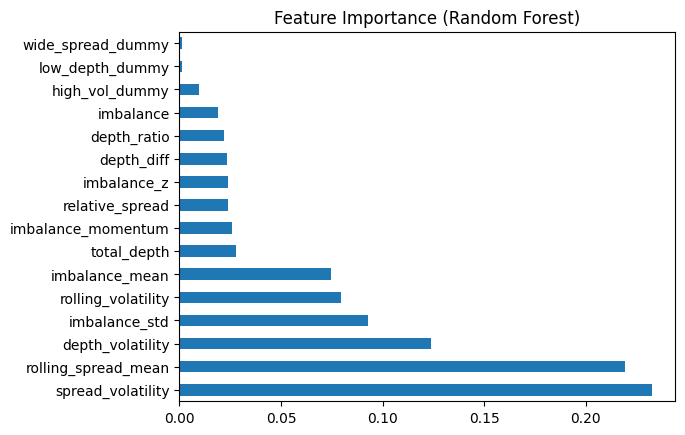

spread_volatility      0.232489
rolling_spread_mean    0.219162
depth_volatility       0.123939
imbalance_std          0.092745
rolling_volatility     0.079456
imbalance_mean         0.074665
total_depth            0.027980
imbalance_momentum     0.025875
relative_spread        0.023844
imbalance_z            0.023796
depth_diff             0.023313
depth_ratio            0.021953
imbalance              0.018895
high_vol_dummy         0.009382
low_depth_dummy        0.001265
wide_spread_dummy      0.001240
dtype: float64


In [70]:
importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure()
importances.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.show()

print(importances)


- While order imbalance features are significant contributors, the model’s predictive power is primarily driven by liquidity-related variables such as spread dynamics and market depth.
- Imbalance plays a complementary role by capturing directional pressure, whereas liquidity variables determine the market’s sensitivity to order flow.

#### Regime-Based Performance Analysis

In [71]:
data["vol_regime"] = data["rolling_volatility"] > data["rolling_volatility"].median()

vol_test = data.loc[X_test.index, "vol_regime"]
preds = model.predict(X_test)
for regime in [True, False]:
    mask = vol_test == regime
    
    acc = accuracy_score(
        y_test[mask],
        preds[mask]
    )
    
    print("Regime:", "High Vol" if regime else "Low Vol")
    print("Accuracy:", acc)
    print("-"*30)



Regime: High Vol
Accuracy: 0.465658475110271
------------------------------
Regime: Low Vol
Accuracy: 0.5247666905958364
------------------------------


- The model exhibits higher predictive accuracy in low-volatility regimes compared to high-volatility periods.
- This indicates that the signal is more informative when market conditions are stable and price dynamics are primarily driven by order flow and liquidity imbalances.
- During volatile periods, the predictive power weakens as price movements become dominated by exogenous shocks and noise, reducing the informational content of microstructure features.

**Conditional Expectation Analysis**

/var/folders/qq/3ztd8n_52dvcv5_12w9h0f2r0000gn/T/ipykernel_44728/3944382436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ml["imbalance_bucket"] = pd.qcut(


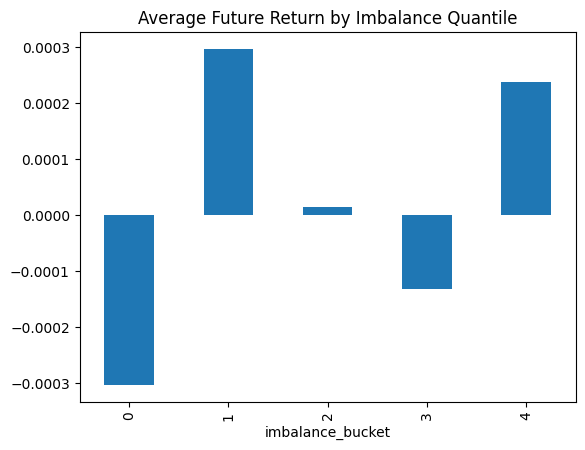

imbalance_bucket
0   -0.000303
1    0.000296
2    0.000014
3   -0.000132
4    0.000237
Name: future_return_1, dtype: float64


In [72]:
data_ml["imbalance_bucket"] = pd.qcut(
    data_ml["imbalance_z"],
    5,
    labels=False
)

cond_returns = (
    data_ml
    .groupby("imbalance_bucket")["future_return_1"]
    .mean()
)

plt.figure()
cond_returns.plot(kind="bar")
plt.title("Average Future Return by Imbalance Quantile")
plt.show()

print(cond_returns)


**Cost Adjusted Signal Check**

In [73]:
data_ml["abs_future_move_1"] = data_ml["future_return_1"].abs()

avg_move = data_ml["abs_future_move_1"].mean()
avg_spread = data_ml["spread"].mean()

print("Average future move (h=1):", avg_move)
print("Average spread:", avg_spread)


Average future move (h=1): 0.00798157567057739
Average spread: 0.01998752018867453


/var/folders/qq/3ztd8n_52dvcv5_12w9h0f2r0000gn/T/ipykernel_44728/2811251096.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ml["abs_future_move_1"] = data_ml["future_return_1"].abs()


In [74]:
# If accuracy declines as horizon increases: Signal is short-lived (microstructure driven)
# If performance collapses in high volatility: Noise destroys imbalance signal
# If imbalance_z ranks high: Extreme liquidity pressure matters
# Important: Signal presence ≠ tradable edge. Execution costs must be modeled next.

- 1. Does predictive power decay with horizon?

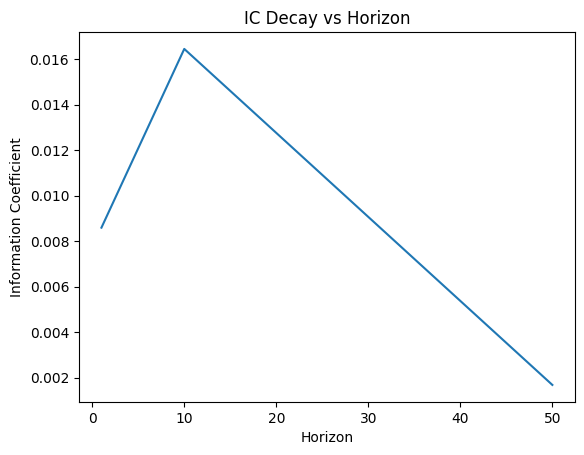

In [75]:
ic_decay = []

for h in horizons:
    ic = data_ml["imbalance_z"].corr(
        data_ml[f"future_return_{h}"]
    )
    ic_decay.append(ic)

plt.figure()
plt.plot(horizons, ic_decay)
plt.title("IC Decay vs Horizon")
plt.xlabel("Horizon")
plt.ylabel("Information Coefficient")
plt.show()


- The information coefficient exhibits a clear decay pattern as the prediction horizon increases.
- Predictability peaks at short horizons, suggesting that the signal captures transient microstructure effects such as order flow imbalance and liquidity dynamics.
- As the horizon increases, the predictive power gradually diminishes, reflecting the rapid incorporation of information into prices and the dominance of noise at longer horizons.
- This behavior is consistent with the short-lived nature of microstructure-based signals.

**Conclusion**

This notebook demonstrates:

✔ Complete Level 1 liquidity analysis  
✔ Economically grounded feature engineering  
✔ Multi-horizon signal validation  
✔ Regime-aware modeling  
